<a href="https://colab.research.google.com/github/Fagerlidk/E_Commerce_Churn_Sentinel/blob/main/E_Commerce_Churn_Sentinel.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install duckdb -q

import pandas as pd
import duckdb
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Hent transaktionsdata (Databricks benchmark datasæt)
url = "https://raw.githubusercontent.com/databricks/Spark-The-Definitive-Guide/master/data/retail-data/all/online-retail-dataset.csv"
print("Henter transaktionsdata... (tager ca. 5-10 sekunder)")
df_raw = pd.read_csv(url)

# 2. Rens manglende kundenumre og konvertér datoer
df_raw = df_raw.dropna(subset=['CustomerID'])
df_raw['CustomerID'] = df_raw['CustomerID'].astype(int)
df_raw['InvoiceDate'] = pd.to_datetime(df_raw['InvoiceDate'])
df_raw['TotalAmount'] = df_raw['Quantity'] * df_raw['UnitPrice']

# Filtrér kreditnotaer og returvarer (negative antal)
df_transactions = df_raw[(df_raw['Quantity'] > 0) & (df_raw['UnitPrice'] > 0)].copy()

print(f"Rå transaktioner klar: {len(df_transactions):,} rækker fordelt på {df_transactions['CustomerID'].nunique():,} unikke kunder.")
df_transactions.head()

Henter transaktionsdata... (tager ca. 5-10 sekunder)
Rå transaktioner klar: 397,884 rækker fordelt på 4,338 unikke kunder.


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalAmount
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34


In [2]:
# Find skæringsdato: Vi bruger de sidste 90 dage som "fremtiden"
max_date = df_transactions['InvoiceDate'].max()
cutoff_date = max_date - pd.Timedelta(days=90)

print(f"Datoperiode starter: {df_transactions['InvoiceDate'].min().date()}")
print(f"Skæringsdato (Cutoff): {cutoff_date.date()}")
print(f"Slutdato: {max_date.date()}")

# SQL QUERY: Udtrækker RFM-nøgletal og definerer Churn
sql_query = f"""
WITH observation_period AS (
    -- Historisk adfærd INDEN skæringsdatoen
    SELECT
        CustomerID,
        COUNT(DISTINCT InvoiceNo) AS total_orders,
        SUM(TotalAmount) AS total_spent,
        AVG(TotalAmount) AS avg_order_item_value,
        SUM(Quantity) AS total_items_bought,
        DATE_DIFF('day', MAX(InvoiceDate), CAST('{cutoff_date}' AS TIMESTAMP)) AS recency_days,
        DATE_DIFF('day', MIN(InvoiceDate), MAX(InvoiceDate)) AS customer_lifespan_days
    FROM df_transactions
    WHERE InvoiceDate < CAST('{cutoff_date}' AS TIMESTAMP)
    GROUP BY CustomerID
),
prediction_period AS (
    -- Kundens aktivitet EFTER skæringsdatoen (Fremtiden)
    SELECT
        DISTINCT CustomerID,
        1 AS bought_in_future
    FROM df_transactions
    WHERE InvoiceDate >= CAST('{cutoff_date}' AS TIMESTAMP)
)
SELECT
    obs.CustomerID,
    obs.total_orders,
    ROUND(obs.total_spent, 2) AS total_spent,
    ROUND(obs.avg_order_item_value, 2) AS avg_order_item_value,
    obs.total_items_bought,
    obs.recency_days,
    obs.customer_lifespan_days,
    -- CHURN DEFINITION: Hvis kunden IKKE handlede i fremtiden = Churn (1), ellers fastholdt (0)
    CASE
        WHEN pred.bought_in_future IS NULL THEN 1
        ELSE 0
    END AS churn
FROM observation_period obs
LEFT JOIN prediction_period pred ON obs.CustomerID = pred.CustomerID;
"""

# Kør SQL direkte i DuckDB
customer_features = duckdb.query(sql_query).to_df()

print(f"\nSQL Feature Engineering gennemført! Kundetabel: {len(customer_features)} kunder.")
print(f"Fordeling af Churn:\n{customer_features['churn'].value_counts(normalize=True).round(3) * 100}%")
customer_features.head()

Datoperiode starter: 2010-12-01
Skæringsdato (Cutoff): 2011-09-10
Slutdato: 2011-12-09

SQL Feature Engineering gennemført! Kundetabel: 3370 kunder.
Fordeling af Churn:
churn
0    57.0
1    43.0
Name: proportion, dtype: float64%


,CustomerID,total_orders,total_spent,avg_order_item_value,total_items_bought,recency_days,customer_lifespan_days,churn
0,17757,20,3320.45,7.79,1803.0,24,258,0
1,14504,3,542.71,5.65,263.0,153,35,0
2,17069,5,1495.79,18.93,712.0,65,218,0
3,16188,3,755.03,14.52,645.0,51,101,0
4,15214,2,651.63,14.17,556.0,93,59,0


=== MODEL EVALUERING PÅ TESTDATA ===
ROC-AUC Score: 0.751

               precision    recall  f1-score   support

Fastholdt (0)       0.72      0.70      0.71       384
    Churn (1)       0.62      0.64      0.63       290

     accuracy                           0.68       674
    macro avg       0.67      0.67      0.67       674
 weighted avg       0.68      0.68      0.68       674



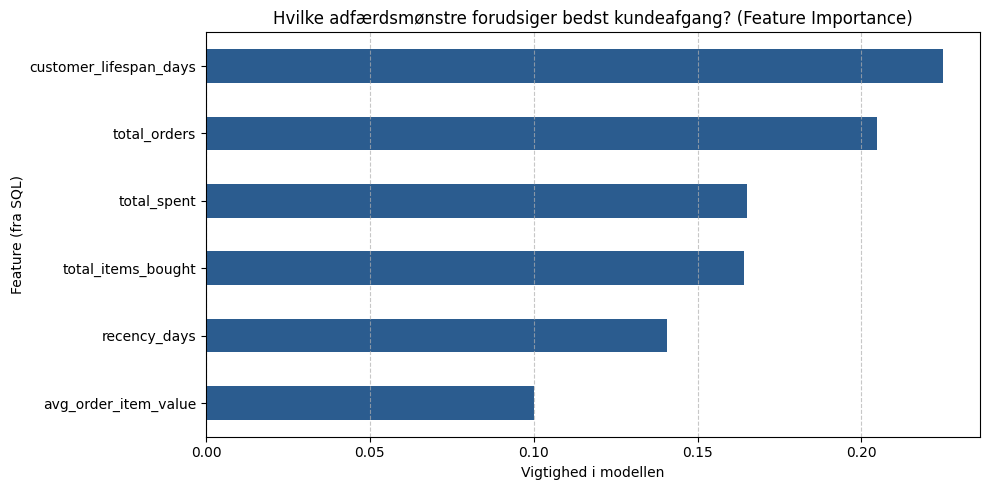

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix

# 1. Klargør features (X) og target (y)
feature_cols = ['total_orders', 'total_spent', 'avg_order_item_value',
                'total_items_bought', 'recency_days', 'customer_lifespan_days']

X = customer_features[feature_cols]
y = customer_features['churn']

# 2. Split i trænings- og test-sæt (80% træning, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)

# 3. Træn en Random Forest model
clf = RandomForestClassifier(n_estimators=100, max_depth=6, random_state=42)
clf.fit(X_train, y_train)

# 4. Evaluér modellen
y_pred = clf.predict(X_test)
y_pred_proba = clf.predict_proba(X_test)[:, 1]

print("=== MODEL EVALUERING PÅ TESTDATA ===")
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_pred_proba):.3f}\n")
print(classification_report(y_test, y_pred, target_names=['Fastholdt (0)', 'Churn (1)']))

# 5. Visualisér: Hvilke features betyder mest for at forudsige churn?
importances = pd.Series(clf.feature_importances_, index=feature_cols).sort_values(ascending=True)

plt.figure(figsize=(10, 5))
importances.plot(kind='barh', color='#2b5c8f')
plt.title('Hvilke adfærdsmønstre forudsiger bedst kundeafgang? (Feature Importance)')
plt.xlabel('Vigtighed i modellen')
plt.ylabel('Feature (fra SQL)')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [4]:
# 1. Beregn sandsynligheder for alle kunder i test-sættet
X_test_eval = X_test.copy()
X_test_eval['churn_probability'] = y_pred_proba
X_test_eval['actual_churn'] = y_test.values

# 2. Find "High-Value At-Risk" kunder (fokus for fastholdelseskampagner)
high_value_at_risk = X_test_eval[
    (X_test_eval['churn_probability'] >= 0.70) &
    (X_test_eval['total_spent'] > X_test_eval['total_spent'].median())
].sort_values(by='total_spent', ascending=False)

print(f"Fundet {len(high_value_at_risk)} højværdikunder med akut risiko for churn.")
high_value_at_risk[['total_spent', 'total_orders', 'recency_days', 'churn_probability']].head(10)

Fundet 1 højværdikunder med akut risiko for churn.


,total_spent,total_orders,recency_days,churn_probability
3228,944.1,2,178,0.711371


In [5]:
# 1. Forudsig churn-risiko for HELE kundebasen
customer_features['churn_risk'] = clf.predict_proba(customer_features[feature_cols])[:, 1]

# 2. Definer grænser for forretningssegmentering
spend_median = customer_features['total_spent'].median()
risk_threshold = 0.50  # En realistisk 50% grænse

# 3. Tildel segmenter
def segmenter_kunde(row):
    if row['churn_risk'] >= risk_threshold and row['total_spent'] >= spend_median:
        return '🚨 Høj Værdi / Høj Risiko (Redningsaktion)'
    elif row['churn_risk'] < risk_threshold and row['total_spent'] >= spend_median:
        return '⭐ VIP / Sikre Stamkunder'
    elif row['churn_risk'] >= risk_threshold and row['total_spent'] < spend_median:
        return '📉 Lav Værdi / Høj Risiko (Masse-flow)'
    else:
        return '🌱 Mindre loyale / Vækstpotentiale'

customer_features['segment'] = customer_features.apply(segmenter_kunde, axis=1)

# 4. Forretningsoverblik: Hvor mange penge er i fare?
summary = customer_features.groupby('segment').agg(
    antal_kunder=('CustomerID', 'count'),
    total_omsætning=('total_spent', 'sum'),
    gns_omsætning=('total_spent', 'mean'),
    gns_dage_siden_køb=('recency_days', 'mean')
).round(1)

summary['pct_af_kunder'] = ((summary['antal_kunder'] / len(customer_features)) * 100).round(1).astype(str) + '%'
summary = summary.sort_values(by='total_omsætning', ascending=False)

print("=== FORRETNINGENS KUNDESEGMENTER & OMSÆTNING PÅ SPIL ===")
display(summary[['antal_kunder', 'pct_af_kunder', 'total_omsætning', 'gns_omsætning', 'gns_dage_siden_køb']])

=== FORRETNINGENS KUNDESEGMENTER & OMSÆTNING PÅ SPIL ===


,antal_kunder,pct_af_kunder,total_omsætning,gns_omsætning,gns_dage_siden_køb
segment,,,,,
⭐ VIP / Sikre Stamkunder,1476,43.8%,4600632.1,3117.0,47.9
🚨 Høj Værdi / Høj Risiko (Redningsaktion),209,6.2%,392464.5,1877.8,144.1
📉 Lav Værdi / Høj Risiko (Masse-flow),1297,38.5%,314716.8,242.6,152.1
🌱 Mindre loyale / Vækstpotentiale,388,11.5%,147591.7,380.4,56.6


/tmp/ipykernel_2141/1165643199.py:62: UserWarning: Glyph 11088 (\N{WHITE MEDIUM STAR}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2141/1165643199.py:62: UserWarning: Glyph 128680 (\N{POLICE CARS REVOLVING LIGHT}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2141/1165643199.py:62: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2141/1165643199.py:62: UserWarning: Glyph 127793 (\N{SEEDLING}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2141/1165643199.py:65: UserWarning: Glyph 11088 (\N{WHITE MEDIUM STAR}) missing from font(s) DejaVu Sans.
  plt.savefig('churn_customer_matrix.png', dpi=300, bbox_inches='tight')
/tmp/ipykernel_2141/1165643199.py:65: UserWarning: Glyph 128680 (\N{POLICE CARS REVOLVING LIGHT}) missing from font(s) DejaVu Sans.
  plt.savefig('churn_customer_matrix.png', dpi=300, bbox_inches='tight')
/tmp/ipykernel_2141/

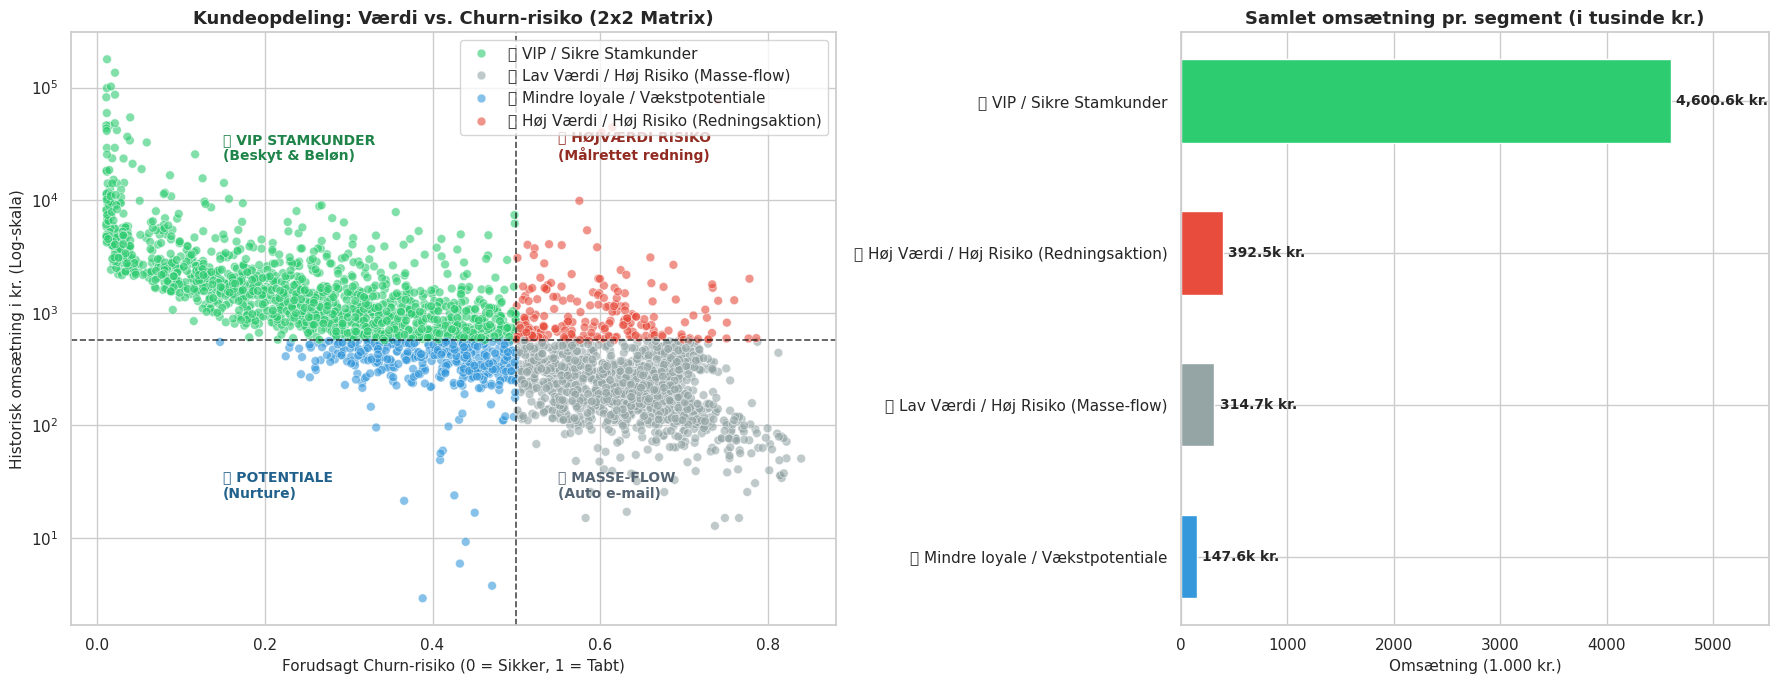

Visualisering gemt som 'churn_customer_matrix.png'!


In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Opsætning af lærred
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(18, 7), gridspec_kw={'width_ratios': [1.3, 1]})

# Farvepalette matchende segmenterne
farver = {
    '⭐ VIP / Sikre Stamkunder': '#2ecc71',
    '🚨 Høj Værdi / Høj Risiko (Redningsaktion)': '#e74c3c',
    '📉 Lav Værdi / Høj Risiko (Masse-flow)': '#95a5a6',
    '🌱 Mindre loyale / Vækstpotentiale': '#3498db'
}

# --- GRAF 1: 2x2 Beslutningsmatrix (Log-skala på omsætning for læsbarhed) ---
sns.scatterplot(
    data=customer_features,
    x='churn_risk',
    y='total_spent',
    hue='segment',
    palette=farver,
    alpha=0.6,
    s=40,
    ax=axes[0]
)

# Kvadranternes skæringslinjer
axes[0].axvline(risk_threshold, color='black', linestyle='--', linewidth=1.2, alpha=0.7)
axes[0].axhline(spend_median, color='black', linestyle='--', linewidth=1.2, alpha=0.7)

# Logaritmisk akse på omsætning pga. store VIP-kunder
axes[0].set_yscale('log')
axes[0].set_title('Kundeopdeling: Værdi vs. Churn-risiko (2x2 Matrix)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Forudsagt Churn-risiko (0 = Sikker, 1 = Tabt)', fontsize=11)
axes[0].set_ylabel('Historisk omsætning i kr. (Log-skala)', fontsize=11)
axes[0].legend(loc='upper right', frameon=True)

# Tilføj forklarende tekst i kvadranterne
axes[0].text(0.15, spend_median * 40, '⭐ VIP STAMKUNDER\n(Beskyt & Beløn)', fontsize=10, fontweight='bold', color='#1e8449')
axes[0].text(0.55, spend_median * 40, '🚨 HØJVÆRDI RISIKO\n(Målrettet redning)', fontsize=10, fontweight='bold', color='#922b21')
axes[0].text(0.55, spend_median / 25, '📉 MASSE-FLOW\n(Auto e-mail)', fontsize=10, fontweight='bold', color='#566573')
axes[0].text(0.15, spend_median / 25, '🌱 POTENTIALE\n(Nurture)', fontsize=10, fontweight='bold', color='#21618c')

# --- GRAF 2: Omsætning på spil (Søjlediagram) ---
oms_data = summary.sort_values(by='total_omsætning', ascending=True)
søjle_farver = [farver[seg] for seg in oms_data.index]

barer = axes[1].barh(oms_data.index, oms_data['total_omsætning'] / 1000, color=søjle_farver, height=0.55)
axes[1].set_title('Samlet omsætning pr. segment (i tusinde kr.)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Omsætning (1.000 kr.)', fontsize=11)

# Værdilabels for enden af søjlerne
for bar in barer:
    bredde = bar.get_width()
    axes[1].text(bredde + 50, bar.get_y() + bar.get_height()/2, f"{bredde:,.1f}k kr.",
                 va='center', ha='left', fontsize=10, fontweight='bold')

axes[1].set_xlim(0, (oms_data['total_omsætning'].max() / 1000) * 1.2)

plt.tight_layout()

# Gem visualiseringen i høj opløsning
plt.savefig('churn_customer_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

print("Visualisering gemt som 'churn_customer_matrix.png'!")